In [70]:
from dotenv import load_dotenv 
load_dotenv()

True

In [71]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END 
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field 
from typing import Literal
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool
import requests, os

In [72]:
class FlowState(BaseModel) : 
    question : str = Field(description="User Asked Question")
    category : Literal['coding', 'google_search', 'weather'] = Field(default='google_search')
    answer : str = Field(default="")

In [73]:
class QuestionCategory(BaseModel) : 
    category : Literal['coding', 'google_search', 'weather'] = Field(default='google_search', description='Question Category')

In [74]:
llm = ChatGroq(model="qwen/qwen3.8-27b")

In [75]:
### define your agents - Google Search Agent , Weather Agent 

search = GoogleSerperAPIWrapper()
tools = [search.run]

google_agent = create_agent(
    model = llm, 
    tools = tools, 
    system_prompt="You are an agent and can search any question on google."
)

## weather agent 
@tool
def get_weather(city: str) -> str:
    """
    It provides real time weather details for any city.
    """
    API_KEY = os.getenv("WEATHER_API_KEY")
    url = f"http://weatherapi.com{API_KEY}&q={city}&aqi=no"
    
    try:
        response = requests.get(url)
        response.raise_for_status() 
        data = response.json()
        
        location_name = data["location"]["name"]
        temp_c = data["current"]["temp_c"]
        condition = data["current"]["condition"]["text"]
        
        return f"The current temperature in {location_name} is {temp_c}°C ({condition})."
        
    except requests.exceptions.RequestException as e:
        return f"Could not fetch weather data for '{city}'. Error: {str(e)}"

weather_agent = create_agent(
    model = llm, 
    tools = [get_weather], 
    system_prompt="You are an agent and can provide real-time weather details"
)

In [76]:
def check_question_category(state : FlowState) -> FlowState : 
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I Want to know the category of my question, question is : {state.question}. If you are not sure, then just give 'google_search as the category")
    print(res)
    state.category = res.category
    return state

In [77]:
flow = FlowState(question="I want to write the code in Python")
check_question_category(flow)

category='coding'


FlowState(question='I want to write the code in Python', category='coding', answer='')

In [78]:
def route(state : FlowState) -> Literal['coding', 'google_search', 'weather'] : 
    return state.category

In [79]:
def coding_node(state : FlowState) -> FlowState : 
    res = llm.invoke(f"You are a coding expert : {state.question}")
    state.answer = res.content
    return state

In [80]:
def weather_node(state : FlowState) -> FlowState : 
    res = weather_agent.invoke({"messages" : [{"role" : "user", "content" : state.question}]})
    state.answer = res["messages"][-1].content
    return state

In [81]:
def google_search_node(state : FlowState) -> FlowState : 
    res = google_agent.invoke({"messages" : [{"role" : "user", "content" : state.question}]})
    state.answer = res["messages"][-1].content
    return state

In [82]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

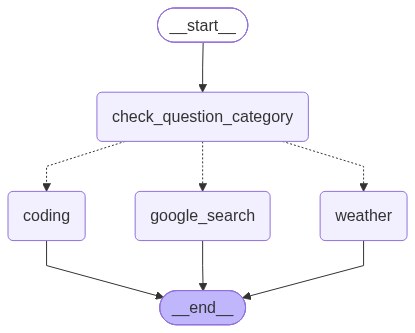

In [83]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [84]:
response = graph.invoke({"question" : "Write a code to find odd or even number in Java."})

category='coding'


In [85]:
print(response["answer"])

# Java Program to Check Odd or Even Number

Here's a clean, well-structured Java program that checks whether a given number is odd or even:

```java
import java.util.Scanner;

public class OddEvenChecker {

    /**
     * Determines if a number is even or odd.
     *
     * @param number the integer to check
     * @return "even" if the number is even, "odd" otherwise
     */
    public static String checkOddEven(int number) {
        if (number % 2 == 0) {
            return "even";
        } else {
            return "odd";
        }
    }

    public static void main(String[] args) {
        Scanner scanner = new Scanner(System.in);

        // Get input from user
        System.out.print("Enter an integer: ");
        int number = scanner.nextInt();

        // Determine and display result
        String result = checkOddEven(number);
        System.out.println(number + " is " + result);

        // Close the scanner
        scanner.close();
    }
}
```

## How It Works

1. **Modul

In [86]:
response = graph.invoke({"question" : "What is the address of TechSimplUS "})

category='google_search'


In [87]:
response

{'question': 'What is the address of TechSimplUS ',
 'category': 'google_search',
 'answer': 'Based on search results, **TechSimPlus** (TechSimplUS) is located in **Bhopal, Madhya Pradesh, India**. Their registered/primary address is:\n\n**PLOT NO. 53, SECTOR C, Indrapuri, Raisen Road, Anand Nagar, Bhopal, Madhya Pradesh, 462022, India**\n\nSome sources also list a studio address at: 2nd Floor, 53-C, Near Yadav Tea Stall, Indrapuri, Bhopal - 462021.\n\n**Contact:** +91 98937-62256 | info@techsimplus.com'}

In [90]:
response = graph.invoke({"question" : "What is the temperature in NewYork?"})

category='weather'


In [91]:
response

{'question': 'What is the temperature in NewYork?',
 'category': 'weather',
 'answer': 'Unfortunately, I couldn\'t retrieve the current weather data for New York due to a technical error with the weather service.\n\nHowever, you can easily check the current temperature by:\n- Searching "New York weather" in your browser\n- Checking a weather app on your phone\n- Visiting [weather.com](https://weather.com) or [accuweather.com](https://www.accuweather.com)\n\nWould you like me to try again, or is there anything else I can help you with?'}